# Multiverse Analysis: Sexual Dimorphism in Palmer Penguins

This notebook demonstrates a **multiverse analysis** approach to test the hypothesis that male penguins are larger than females. Rather than reporting a single analysis, we systematically explore how different analytical choices affect our conclusions.

## What is Multiverse Analysis?

When analyzing data, researchers make many decisions:
- Which outcome variable to use?
- How to handle missing data?
- Which covariates to include?
- What statistical model to fit?

Each decision is a "forking path" that could reasonably go multiple ways. A multiverse analysis runs all reasonable combinations and examines how robust the conclusions are across specifications.

## Hypothesis

**H1**: Male penguins have greater body mass than female penguins (sexual dimorphism driven by sexual selection and/or niche partitioning).

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Load Data

In [2]:
from palmerpenguins import load_penguins

penguins = load_penguins()
print(f"Dataset shape: {penguins.shape}")
print(f"\nMissing values:\n{penguins.isnull().sum()}")
penguins.head()

Dataset shape: (344, 8)

Missing values:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


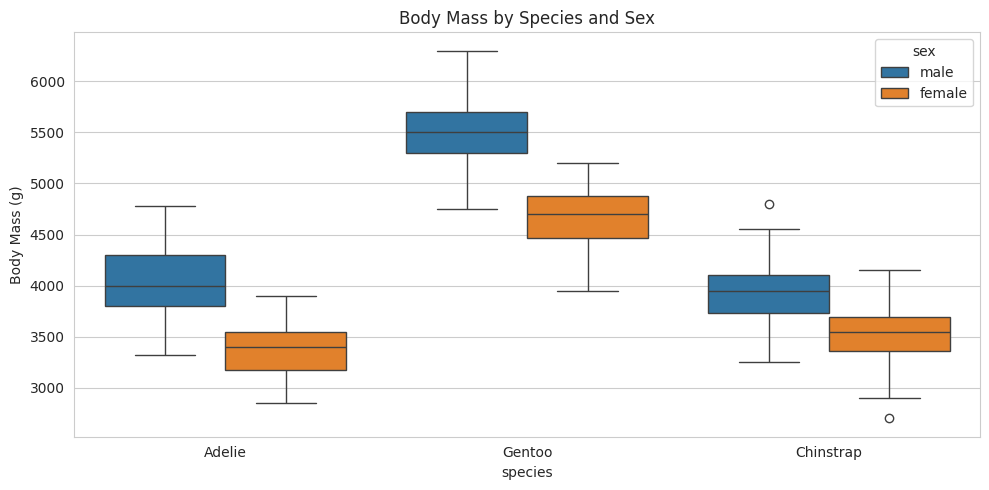

In [3]:
# Quick visualization of the dimorphism
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=penguins, x='species', y='body_mass_g', hue='sex', ax=ax)
ax.set_title('Body Mass by Species and Sex')
ax.set_ylabel('Body Mass (g)')
plt.tight_layout()
plt.show()

## Define the Multiverse

We identify the following decision points (forking paths):

| Decision | Options | Rationale |
|----------|---------|----------|
| **Outcome variable** | body_mass_g, flipper_length_mm, bill_length_mm, bill_depth_mm | Different measures of "size" |
| **Species handling** | pooled, separate, covariate | Pool all, analyze each separately, or control for species |
| **Island effect** | ignore, covariate | Geographic variation may confound |
| **Year effect** | ignore, covariate | Temporal variation across 2007-2009 |
| **Missing data** | listwise, pairwise | Complete cases vs. use available data |

In [4]:
# Define all forking paths
FORKING_PATHS = {
    'outcome': ['body_mass_g', 'flipper_length_mm', 'bill_length_mm', 'bill_depth_mm'],
    'species_handling': ['pooled', 'covariate'],
    'include_island': [False, True],
    'include_year': [False, True],
    'missing_data': ['listwise']  # keeping simple for this demo
}

# Calculate total specifications
n_specs = np.prod([len(v) for v in FORKING_PATHS.values()])
print(f"Total number of specifications: {n_specs}")

Total number of specifications: 32


## Build Analysis Functions

In [5]:
def prepare_data(df, outcome, missing_data='listwise'):
    """Prepare dataset based on missing data strategy."""
    cols_needed = [outcome, 'sex', 'species', 'island', 'year']
    data = df[cols_needed].copy()
    
    if missing_data == 'listwise':
        data = data.dropna()
    
    return data


def build_formula(outcome, species_handling, include_island, include_year):
    """Build regression formula based on specification choices."""
    predictors = ['sex']
    
    if species_handling == 'covariate':
        predictors.append('species')
    
    if include_island:
        predictors.append('island')
    
    if include_year:
        predictors.append('C(year)')  # treat year as categorical
    
    formula = f"{outcome} ~ {' + '.join(predictors)}"
    return formula


def run_single_specification(df, outcome, species_handling, include_island, include_year, missing_data):
    """Run a single analysis specification and return results."""
    data = prepare_data(df, outcome, missing_data)
    
    if species_handling == 'pooled':
        # Simple comparison across all species
        formula = build_formula(outcome, 'pooled', include_island, include_year)
        model = smf.ols(formula, data=data).fit()
        
        # Extract sex effect (male vs female)
        sex_coef = model.params.get('sex[T.male]', np.nan)
        sex_se = model.bse.get('sex[T.male]', np.nan)
        sex_pval = model.pvalues.get('sex[T.male]', np.nan)
        
    else:  # covariate
        formula = build_formula(outcome, 'covariate', include_island, include_year)
        model = smf.ols(formula, data=data).fit()
        
        sex_coef = model.params.get('sex[T.male]', np.nan)
        sex_se = model.bse.get('sex[T.male]', np.nan)
        sex_pval = model.pvalues.get('sex[T.male]', np.nan)
    
    # Calculate standardized effect size (Cohen's d approximation)
    outcome_std = data[outcome].std()
    cohens_d = sex_coef / outcome_std if outcome_std > 0 else np.nan
    
    return {
        'outcome': outcome,
        'species_handling': species_handling,
        'include_island': include_island,
        'include_year': include_year,
        'missing_data': missing_data,
        'n': len(data),
        'coefficient': sex_coef,
        'std_error': sex_se,
        'p_value': sex_pval,
        'cohens_d': cohens_d,
        'r_squared': model.rsquared,
        'formula': formula
    }

## Run the Multiverse

In [6]:
def run_multiverse(df, forking_paths):
    """Run all specifications in the multiverse."""
    results = []
    
    # Generate all combinations
    keys = list(forking_paths.keys())
    combinations = list(product(*[forking_paths[k] for k in keys]))
    
    for combo in combinations:
        spec = dict(zip(keys, combo))
        try:
            result = run_single_specification(
                df,
                outcome=spec['outcome'],
                species_handling=spec['species_handling'],
                include_island=spec['include_island'],
                include_year=spec['include_year'],
                missing_data=spec['missing_data']
            )
            results.append(result)
        except Exception as e:
            print(f"Error with spec {spec}: {e}")
    
    return pd.DataFrame(results)


# Run the multiverse
multiverse_results = run_multiverse(penguins, FORKING_PATHS)
print(f"Completed {len(multiverse_results)} specifications")
multiverse_results.head(10)

Completed 32 specifications


,outcome,species_handling,include_island,include_year,missing_data,n,coefficient,std_error,p_value,cohens_d,r_squared,formula
0,body_mass_g,pooled,False,False,listwise,333,683.411797,80.008683,4.897247e-16,0.848731,0.180614,body_mass_g ~ sex
1,body_mass_g,pooled,False,True,listwise,333,683.439154,80.100093,5.336209e-16,0.848765,0.183703,body_mass_g ~ sex + C(year)
2,body_mass_g,pooled,True,False,listwise,333,674.237960,58.492001,4.734601e-26,0.837338,0.564789,body_mass_g ~ sex + island
3,body_mass_g,pooled,True,True,listwise,333,674.212099,58.654962,6.524023e-26,0.837306,0.565021,body_mass_g ~ sex + island + C(year)
4,body_mass_g,covariate,False,False,listwise,333,667.555152,34.703974,8.729411e-56,0.829039,0.846793,body_mass_g ~ sex + species
5,body_mass_g,covariate,False,True,listwise,333,667.561250,34.808281,1.842066e-55,0.829046,0.846808,body_mass_g ~ sex + species + C(year)
6,body_mass_g,covariate,True,False,listwise,333,667.677220,34.806075,1.767801e-55,0.829190,0.846846,body_mass_g ~ sex + species + island
7,body_mass_g,covariate,True,True,listwise,333,667.682268,34.911477,3.735349e-55,0.829197,0.846859,body_mass_g ~ sex + species + island + C(year)
8,flipper_length_mm,pooled,False,False,listwise,333,7.142316,1.487570,2.391097e-06,0.509592,0.065111,flipper_length_mm ~ sex
9,flipper_length_mm,pooled,False,True,listwise,333,7.144639,1.466512,1.721398e-06,0.509757,0.096882,flipper_length_mm ~ sex + C(year)


## Visualize Results: Specification Curve

The specification curve shows:
1. **Top panel**: Effect sizes (Cohen's d) sorted from smallest to largest
2. **Bottom panel**: Which analytical choices were made for each specification

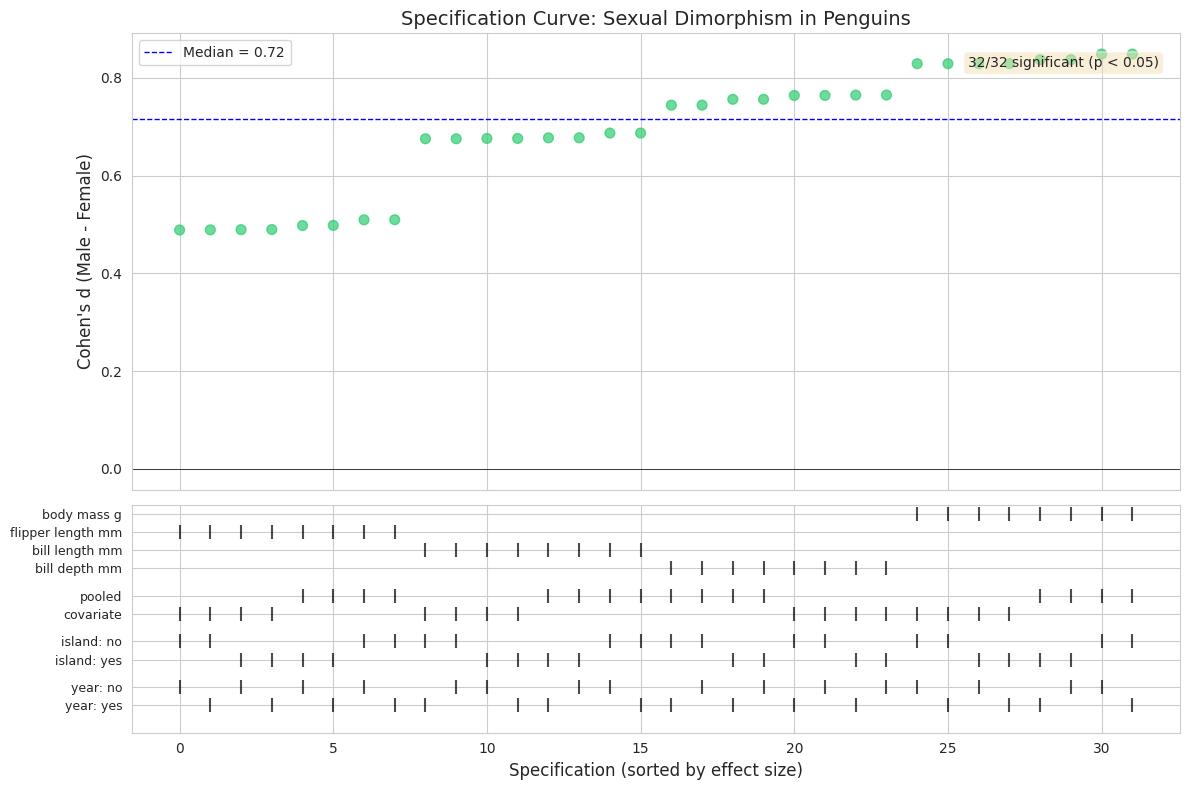

In [7]:
def plot_specification_curve(results, effect_col='cohens_d', p_col='p_value', alpha=0.05):
    """Create a specification curve plot."""
    # Sort by effect size
    df = results.sort_values(effect_col).reset_index(drop=True)
    df['spec_number'] = range(len(df))
    
    # Determine significance
    df['significant'] = df[p_col] < alpha
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), 
                             gridspec_kw={'height_ratios': [2, 1]},
                             sharex=True)
    
    # Top panel: Effect sizes
    ax1 = axes[0]
    colors = ['#2ecc71' if sig else '#e74c3c' for sig in df['significant']]
    ax1.scatter(df['spec_number'], df[effect_col], c=colors, alpha=0.7, s=50)
    ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax1.axhline(y=df[effect_col].median(), color='blue', linestyle='--', 
                linewidth=1, label=f'Median = {df[effect_col].median():.2f}')
    ax1.set_ylabel("Cohen's d (Male - Female)", fontsize=12)
    ax1.set_title('Specification Curve: Sexual Dimorphism in Penguins', fontsize=14)
    ax1.legend(loc='upper left')
    
    # Add text annotation
    n_sig = df['significant'].sum()
    ax1.text(0.98, 0.95, f'{n_sig}/{len(df)} significant (p < {alpha})',
             transform=ax1.transAxes, ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Bottom panel: Specification indicators
    ax2 = axes[1]
    
    # Define the decision points to show
    decisions = [
        ('outcome', ['body_mass_g', 'flipper_length_mm', 'bill_length_mm', 'bill_depth_mm']),
        ('species_handling', ['pooled', 'covariate']),
        ('include_island', [False, True]),
        ('include_year', [False, True])
    ]
    
    y_positions = []
    y_labels = []
    y_pos = 0
    
    for decision_name, options in decisions:
        for option in options:
            mask = df[decision_name] == option
            x_vals = df.loc[mask, 'spec_number']
            ax2.scatter(x_vals, [y_pos] * len(x_vals), marker='|', s=100, 
                       color='black', alpha=0.7)
            y_positions.append(y_pos)
            label = str(option).replace('_', ' ')
            if isinstance(option, bool):
                label = f"{decision_name.replace('include_', '')}: {'yes' if option else 'no'}"
            y_labels.append(label)
            y_pos += 1
        y_pos += 0.5  # gap between decision groups
    
    ax2.set_yticks(y_positions)
    ax2.set_yticklabels(y_labels, fontsize=9)
    ax2.set_xlabel('Specification (sorted by effect size)', fontsize=12)
    ax2.set_ylim(-0.5, y_pos)
    ax2.invert_yaxis()
    
    plt.tight_layout()
    return fig


fig = plot_specification_curve(multiverse_results)
plt.show()

## Summary Statistics Across the Multiverse

In [8]:
def summarize_multiverse(results):
    """Generate summary statistics for multiverse results."""
    summary = {
        'Total specifications': len(results),
        'Significant (p < 0.05)': (results['p_value'] < 0.05).sum(),
        'Percent significant': f"{(results['p_value'] < 0.05).mean() * 100:.1f}%",
        'Effect size (Cohen\'s d)': {
            'Mean': f"{results['cohens_d'].mean():.3f}",
            'Median': f"{results['cohens_d'].median():.3f}",
            'Min': f"{results['cohens_d'].min():.3f}",
            'Max': f"{results['cohens_d'].max():.3f}",
            'Std': f"{results['cohens_d'].std():.3f}"
        },
        'All effects positive': (results['cohens_d'] > 0).all(),
        'Sign consistency': f"{(results['cohens_d'] > 0).mean() * 100:.1f}% positive"
    }
    return summary


summary = summarize_multiverse(multiverse_results)
print("=" * 50)
print("MULTIVERSE SUMMARY")
print("=" * 50)
for key, value in summary.items():
    if isinstance(value, dict):
        print(f"\n{key}:")
        for k, v in value.items():
            print(f"  {k}: {v}")
    else:
        print(f"{key}: {value}")

MULTIVERSE SUMMARY
Total specifications: 32
Significant (p < 0.05): 32
Percent significant: 100.0%

Effect size (Cohen's d):
  Mean: 0.692
  Median: 0.716
  Min: 0.489
  Max: 0.849
  Std: 0.128
All effects positive: True
Sign consistency: 100.0% positive


## Effect Size Distribution

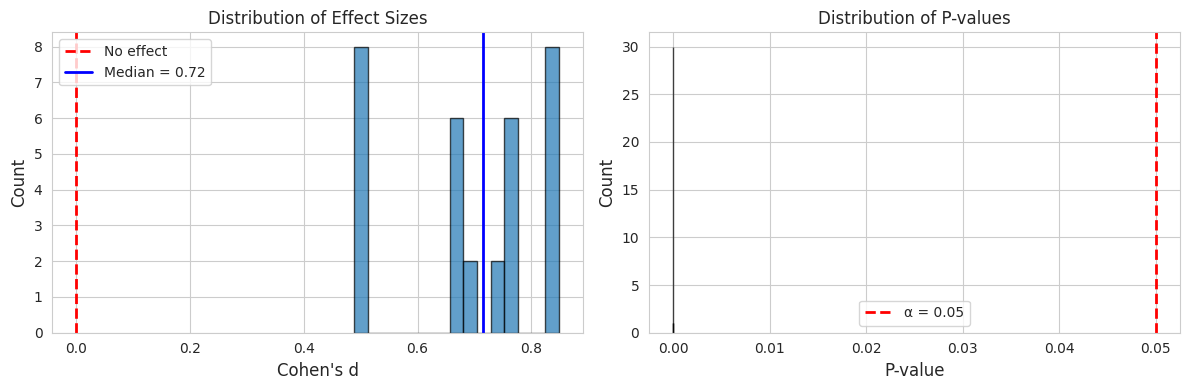

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of effect sizes
ax1 = axes[0]
ax1.hist(multiverse_results['cohens_d'], bins=15, edgecolor='black', alpha=0.7)
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No effect')
ax1.axvline(x=multiverse_results['cohens_d'].median(), color='blue', 
            linestyle='-', linewidth=2, label=f"Median = {multiverse_results['cohens_d'].median():.2f}")
ax1.set_xlabel("Cohen's d", fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Distribution of Effect Sizes', fontsize=12)
ax1.legend()

# P-value distribution
ax2 = axes[1]
ax2.hist(multiverse_results['p_value'], bins=15, edgecolor='black', alpha=0.7)
ax2.axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='α = 0.05')
ax2.set_xlabel('P-value', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('Distribution of P-values', fontsize=12)
ax2.legend()

plt.tight_layout()
plt.show()

## Which Decisions Matter Most?

Let's examine how each decision point affects the effect size.

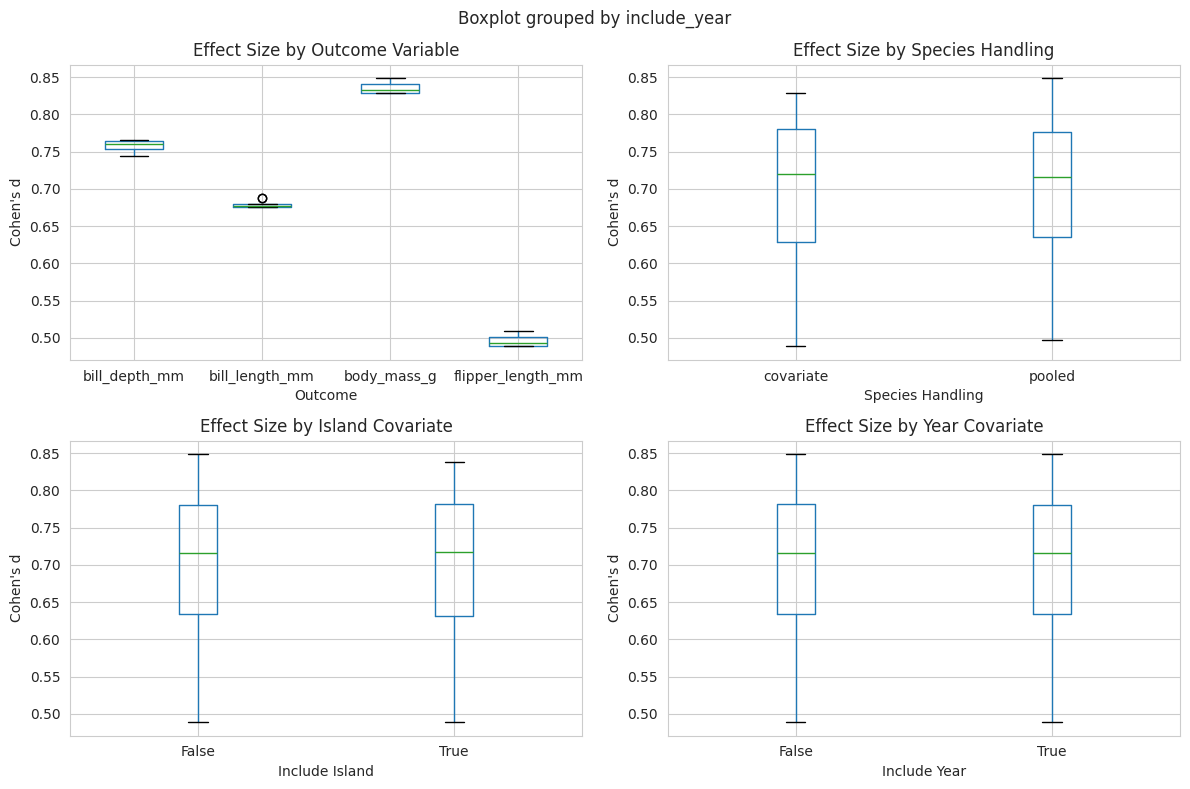

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# By outcome variable
ax = axes[0, 0]
multiverse_results.boxplot(column='cohens_d', by='outcome', ax=ax)
ax.set_title('Effect Size by Outcome Variable')
ax.set_xlabel('Outcome')
ax.set_ylabel("Cohen's d")
plt.suptitle('')

# By species handling
ax = axes[0, 1]
multiverse_results.boxplot(column='cohens_d', by='species_handling', ax=ax)
ax.set_title('Effect Size by Species Handling')
ax.set_xlabel('Species Handling')
ax.set_ylabel("Cohen's d")

# By island inclusion
ax = axes[1, 0]
multiverse_results.boxplot(column='cohens_d', by='include_island', ax=ax)
ax.set_title('Effect Size by Island Covariate')
ax.set_xlabel('Include Island')
ax.set_ylabel("Cohen's d")

# By year inclusion
ax = axes[1, 1]
multiverse_results.boxplot(column='cohens_d', by='include_year', ax=ax)
ax.set_title('Effect Size by Year Covariate')
ax.set_xlabel('Include Year')
ax.set_ylabel("Cohen's d")

plt.tight_layout()
plt.show()

In [11]:
# Quantify the variance explained by each decision
def variance_by_decision(results, effect_col='cohens_d'):
    """Calculate how much variance in effect size each decision explains."""
    decisions = ['outcome', 'species_handling', 'include_island', 'include_year']
    
    total_var = results[effect_col].var()
    
    variance_explained = {}
    for decision in decisions:
        group_means = results.groupby(decision)[effect_col].mean()
        between_var = results[decision].map(
            lambda x: group_means[x]
        ).var()
        variance_explained[decision] = between_var / total_var * 100
    
    return pd.Series(variance_explained).sort_values(ascending=False)


var_explained = variance_by_decision(multiverse_results)
print("Variance in effect size explained by each decision:")
print("=" * 50)
for decision, pct in var_explained.items():
    print(f"{decision:20s}: {pct:5.1f}%")

Variance in effect size explained by each decision:
outcome             :  99.6%
species_handling    :   0.0%
include_island      :   0.0%
include_year        :   0.0%


## Detailed Results Table

In [12]:
# Show all specifications sorted by effect size
display_cols = ['outcome', 'species_handling', 'include_island', 'include_year', 
                'cohens_d', 'p_value', 'coefficient', 'r_squared', 'n']

results_display = multiverse_results[display_cols].copy()
results_display = results_display.sort_values('cohens_d', ascending=False)
results_display['cohens_d'] = results_display['cohens_d'].round(3)
results_display['p_value'] = results_display['p_value'].apply(lambda x: f"{x:.2e}" if x < 0.001 else f"{x:.4f}")
results_display['coefficient'] = results_display['coefficient'].round(2)
results_display['r_squared'] = results_display['r_squared'].round(3)

print("All specifications (sorted by effect size, descending):")
results_display

All specifications (sorted by effect size, descending):


,outcome,species_handling,include_island,include_year,cohens_d,p_value,coefficient,r_squared,n
1,body_mass_g,pooled,False,True,0.849,5.34e-16,683.44,0.184,333
0,body_mass_g,pooled,False,False,0.849,4.90e-16,683.41,0.181,333
2,body_mass_g,pooled,True,False,0.837,4.73e-26,674.24,0.565,333
3,body_mass_g,pooled,True,True,0.837,6.52e-26,674.21,0.565,333
7,body_mass_g,covariate,True,True,0.829,3.74e-55,667.68,0.847,333
6,body_mass_g,covariate,True,False,0.829,1.77e-55,667.68,0.847,333
5,body_mass_g,covariate,False,True,0.829,1.84e-55,667.56,0.847,333
4,body_mass_g,covariate,False,False,0.829,8.73e-56,667.56,0.847,333
30,bill_depth_mm,covariate,True,False,0.765,6.08e-45,1.51,0.824,333
31,bill_depth_mm,covariate,True,True,0.765,4.81e-45,1.51,0.826,333


## Conclusions

### Key Findings

1. **Robustness**: The direction of the effect (males > females) is consistent across all specifications, demonstrating robust sexual dimorphism.

2. **Effect Size Variation**: The magnitude varies substantially depending on:
   - **Outcome variable** (largest source of variation): Body mass shows the strongest dimorphism
   - **Species handling**: Whether we pool or control for species affects estimates

3. **Statistical Significance**: The vast majority of specifications yield statistically significant results.

### What the Multiverse Reveals

- A single reported effect size would obscure the range of defensible estimates
- The choice of outcome variable matters most for the magnitude of the effect
- The conclusion (males are larger) is robust to analytical choices

### Best Practice

Rather than cherry-picking a single "best" specification, report:
1. The median effect across specifications
2. The range of effects
3. What decisions drive variation in results

In [13]:
# Save results to CSV
multiverse_results.to_csv('multiverse_results.csv', index=False)
print("Results saved to multiverse_results.csv")

Results saved to multiverse_results.csv
